# 00 — GeoLibre quickstart in JupyterLite

> **Required runtime:** this notebook uses `geolibre_lite.LiteMap`, not upstream `geolibre.Map`.


## See the connections

![Browser GIS: from source to understanding: Sources: GeoJSON vectors, COG rasters, PMTiles; Coordinates: GeoJSON stores longitude before latitude; Representations: The map links values to their locations; Check: Keep units, attribution and view settings](assets/00_mindmap.svg)

In [1]:
import sys
if sys.platform == "emscripten":
    import micropip
    await micropip.install("geolibre==3.0.0")
from geolibre_lite import LiteMap as Map
assert Map.__module__ == "geolibre_lite", f"Wrong Map loaded: {Map.__module__}"
print("Map implementation:", Map.__module__)


Map implementation: geolibre_lite


In [2]:
m = Map(center=(-98, 39), zoom=3, height="650px")
m.add_geojson(
    "https://assets.geolibre.app/data/places.geojson",
    name="GeoLibre sample places",
)
m.add_cog(
    "https://data.source.coop/giswqs/opengeos/dem.tif",
    name="Public DEM COG",
    colormap="terrain",
)
m


## Try it

Use GeoLibre's layer panel to change opacity and styling, then open **Processing** to inspect the browser GIS tools. Because the raster is a cloud-optimized GeoTIFF, GeoLibre can request only the byte ranges needed for the current view.

For a reproducible project, keep the source URL and styling parameters in code rather than relying only on manual UI state.


In [3]:
project = m.to_project()
print("Project keys:", project.keys())


Project keys: dict_keys(['version', 'name', 'mapView', 'basemapStyleUrl', 'basemapVisible', 'basemapOpacity', 'layers', 'styles', 'preferences', 'metadata'])


## Data & software citations

- GeoLibre: https://geolibre.app/ — MIT-licensed upstream project.
- GeoLibre hosted sample: `https://assets.geolibre.app/data/places.geojson`.
- Public DEM demo asset: Source Cooperative / Open Geospatial Solutions, https://source.coop/giswqs/opengeos.
- Basemap attribution, when OpenStreetMap-derived tiles are shown: © OpenStreetMap contributors, https://www.openstreetmap.org/copyright.

See the repository `DATA_SOURCES.md` for the consolidated source register.


In [4]:
from IPython.display import display
import sys
if sys.platform == "emscripten":
    from pyodide import loadPackage
    await loadPackage("matplotlib")

## Visual experiment: longitude is the x coordinate

Predict which marker is east, then read both the map and the coordinate diagram. These are illustrative points in a local patch. Changing a coordinate changes location; changing color only changes its representation.

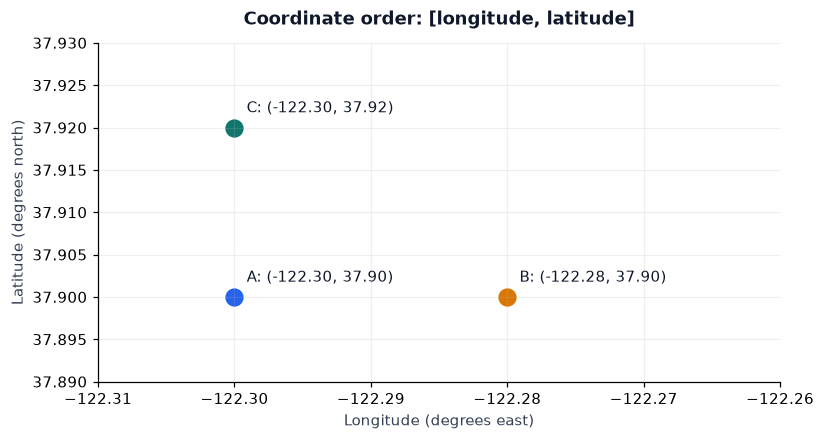

In [5]:
from cognition import style_plots
import matplotlib.pyplot as plt
style_plots()
points = {"A": (-122.30, 37.90), "B": (-122.28, 37.90), "C": (-122.30, 37.92)}
fig, ax = plt.subplots(figsize=(8, 4))
for label, (x, y) in points.items():
    ax.scatter(x, y, s=120)
    ax.annotate(f"{label}: ({x:.2f}, {y:.2f})", (x, y), xytext=(8, 10), textcoords="offset points")
ax.set(xlabel="Longitude (degrees east)", ylabel="Latitude (degrees north)",
       title="Coordinate order: [longitude, latitude]", xlim=(-122.31, -122.26), ylim=(37.89, 37.93))
ax.ticklabel_format(useOffset=False)
ax.grid(alpha=.2)
plt.show()
coordinate_map = Map(center=(-122.29, 37.91), zoom=12, height="450px")
for label, (lon, lat) in points.items():
    coordinate_map.add_marker(lon, lat, name=label, properties={"label": label, "source": "illustrative"})
display(coordinate_map)

**Explain it:** B is east of A because its longitude is less negative. C is north of A. Why would swapping the two numbers put these points outside valid latitude bounds?